# Demo: Snekmer Learn/Apply


**Snekmer Learn/Apply** is a protein-function annotation framework that represents proteins as **kmer vectors** and uses **cosine similarity** to predict their functional families.   
It operates in two stages:

**Learn**   
Builds a kmer–based model from a curated training set of annotated genomes.
During learning, Snekmer counts k-mers across all training proteins, computes class-specific k-mer signatures, and generates summary statistics (e.g., confidence tables, decoy thresholds).
Increasing the size and diversity of the training set generally improves predictive accuracy.

**Apply** 
Uses the outputs from Learn: kmer signatures, confidence tables, thresholds, and compares them against novel protein sequences or genomes.
For each new protein, Snekmer computes the kmer vector and compares it to the learned signature dataset via cosine similarity, and assigns the most likely family along with a confidence value.


**Demo data** 
In this notebook, we will demonstrate how to use **Snekmer Learn** and **Snkemer Apply** with small training dataset of 10 annotated fasta files and 1 unannotated fasta.

The training set contains 5,000 annotated proteins drawn from 200 TIGRFAM families (50 per family; no unannotated sequences). The test set includes 3,000 proteins balanced across three groups: in-family (selected TIGRFAMs), other annotated families, and unannotated sequences (1000 each).


## Getting Started with Snekmer Learn

### Setup

First, install Snekmer using the instructions in the [user installation guide](https://snekmer.readthedocs.io/en/learn_decoy_implementation/getting_started/install.html).

Before running Snekmer, verify that files have been placed in an **_input_** directory placed at the same level as the **_config.yaml_** file. The assumed file directory structure is illustrated below.

    .
    ├── input
    │   ├── A.fasta
    │   ├── B.fasta
    │   ├── C.fasta
    │   ├── D.fasta
    │   └── etc.
    ├── config.yaml
    ├── annotations
        └── annotations.ann
    
(Note: Snekmer automatically creates the **_output_** directory when creating output files, so there is no need to create this folder in advance.)

To ensure that snekmer is available in the Jupyter notebook do the following in bash after [installing ipykernel](https://pypi.org/project/ipykernel/):
```
source ~/snekmer_env/bin/activate
python -m ipykernel install --user --name=snekmer
jupyter notebook
```

### Annotation File 

The annotation file is a two-columned TSV. The first column, **id**, refers to the **sequence id**. The second column, titled **family**, refers to the family, function, or group to sum on in the kmer-association matrix.

| id               | family    |
| ---------------- | --------- |
| A0A2D0MWR0       | TIGR04183 |
| A0A2D0MY79       | TIGR04131 |
| **A0A1Y4R5C6** | TIGR00722 |


Example of a matching **sequence id** in a fasta file:

\>tr|**A0A1Y4R5C6**|A0A1Y4R5C6_9FIRM Fumarate hydratase OS=Lachnoclostridium sp. An14 OX=1965562 GN=B5E84_18440 PE=3 SV=1
MREIQASQITQAVRDMCIEANYSLSPDMRQRFETAADQEESPLGKMIFGQLKENLDIAQQ
DQIPICQDTGMAVVFVNVGQEVHIDGDLTAAVNEGVRLGYEEGYLRKSVVRDPIERENTR
DNTPAVLHTSLVPGDQVEITVAPKGFGSENMSRIFMLKPADGLEGVKQAILTAVRDAGPN
ACPPMVVGVGIGGTFEKCALMAKHALTRDVNESSPIPYVRELEQEMLNRINGLGIGPGGL
GGAITALAVNIETYPTHIAGLPVAVNICCHVNRHAKRIL

### Notes on Using Snekmer

Snekmer assumes that the user will primarily process input files using the command line. For more detailed instructions, refer to the [README](https://github.com/PNNL-CompBio/Snekmer).

The basic process for running Snekmer Learn/Apply is as follows:

1. Verify that your file directory structure is correct and that the top-level directory contains a **_config.yaml_** file.
    - A **_config.yaml_** template has been included in the Snekmer codebase at **_resources/learn_apply/config.yaml_**.
2. Modify the **_config.yaml_** with the desired parameters.
3. Use the command line to navigate to the directory containing both the **_config.yaml_** file and **_input_** directory.
4. Run `snekmer learn`, then copy the appropriate outputs to a seperate directory to run `snekmer apply`


## Running Snekmer Learn Pipeline

### Setup

**Note:** This notebook assumes you are running it from the **`resources/tutorial/`** directory, where this notebook file is located.

To set up the workflow such that operation mimics the command line implementation of Snekmer Learn/Apply, we will initialize a dictionary (rather than a YAML file) and gather all input files. Input files are detected here using `glob.glob`, exactly as Snekmer performs input file detection.

In [ ]:
# --- Standard library ---
import os, sys, shutil, gzip, pickle
from glob import glob
from pathlib import Path
# --- Third-party ---
import numpy as np
import pandas as pd
from Bio import SeqIO
import matplotlib.pyplot as plt
# --- Snekmer core APIs---
import snekmer as skm
from snekmer.vectorize import KmerVec, reduce, FULL_ALPHABETS
from snekmer.io import read_kmers
# --- Snekmer scripts ---
sys.path.append('../../snekmer/scripts')
import learn_learn, learn_merge, learn_eval_apply_sequences
import learn_eval_apply_reverse_seqs, learn_evaluate_sequences
import learn_reverse_decoy_evaluations
import apply as apply_script

### Build the Tutorial Working Directory (from `demo_sequences`)

This step creates the `learn` and `apply` directories used throughout the notebook by **copying** the demo inputs and annotations from `../demo_sequences/learn_apply_inputs`.

In [20]:
# Build learn apply driectories from demo_sequences
for d in ["learn/input","learn/annotations","apply/input","apply/annotations"]:
    os.makedirs(d, exist_ok=True)
# config
shutil.copy2("../config.yaml","learn/config.yaml")
shutil.copy2("../config.yaml","apply/config.yaml")
# annotations
ann = "../demo_sequences/learn_apply_inputs/annotations/TIGRFAMs_annotation.ann"
shutil.copy2(ann, "learn/annotations/TIGRFAMs_annotation.ann")
# learn inputs
for i in [1,2,3,4,5,6,7,8,9,10]:
    shutil.copy2(f"../demo_sequences/learn_apply_inputs/learn/training_sequences_{i}.fasta",
                 f"learn/input/training_sequences_{i}.fasta")
# apply inputs
for src in glob("../demo_sequences/learn_apply_inputs/apply/test_sequences_*.fasta"):
    shutil.copy2(src, "apply/input/")

### Configuration File Input
Please note, this is a stripped down version of the normal configuration file.

In [21]:
config = {
    ### Base Parameters
    "k": 8,                 # K-mer size
    "alphabet": 2,          # Alphabet selection at https://snekmer.readthedocs.io/en/latest/background/overview.html#alphabets
    ### INPUT HANDLING
    "input": {
        "file_extensions": ["fasta", "fna", "faa", "fa"]
    },
    ### Learn & Apply Parameters
    "learn_apply": {
        "save_apply_associations": False,
        # Fragmentation settings
        "fragmentation": False,     # Please note, the notebook is not set up to use the fragmentation option.
        "version": "absolute",
        "frag_length": 50,
        "min_length": 50,
        "location": "random",
        "seed": 999,
        # Confidence weighting      # This parameter is meant for subsequential data additions and is not supported in the notebook
        "conf_weight_modifier": 20,
        # Selection methods: "top_hit", "greatest_distance", "combined_distance"
        "selection": "top_hit",
        # Threshold column from family_summary_stats.csv or None
        "threshold": "Median",
        # Weights are only relevant if using combined_distance
        "weight_top": 0.5,
        "weight_distance": 0.5,
        # Output naming
        "apply_output": "snekmer_results.csv", # Not applicable in notebook, but this is where final results would be saved.
    },
}

### Rule 0: Collect input files

Before executing the workflow, Snekmer scans the input directory and gathers all files whose extensions match those defined in the configuration (e.g., `.fasta`, `.fa`, and their `.gz`-compressed equivalents). These files must contain protein sequences in FASTA format.

In this notebook, the demo data directory is referenced explicitly at `learn/input/`. However, when using the full Snekmer CLI, the tool expects your files to be organized following the directory structure described in the Setup section above.

In [22]:
# Collect all fasta files. Paths are relative to resources/tutorial/
input_dir = "learn/input/"
unzipped = []
for ext in config["input"]["file_extensions"]:
    unzipped.extend(glob(os.path.join(input_dir, f"*.{ext}")))
print("unzipped files:\t", unzipped)

# Define output directory (and create if missing)
output_dir = "learn/output"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

unzipped files:	 ['learn/input/training_sequences_3.fasta', 'learn/input/training_sequences_1.fasta', 'learn/input/training_sequences_5.fasta', 'learn/input/training_sequences_10.fasta', 'learn/input/training_sequences_7.fasta', 'learn/input/training_sequences_2.fasta', 'learn/input/training_sequences_6.fasta', 'learn/input/training_sequences_4.fasta', 'learn/input/training_sequences_8.fasta', 'learn/input/training_sequences_9.fasta']


### Vectorize Helper Function
This helper function replicates the k-mer vectorization step normally performed inside the Snakemake workflow (kmerize, vectorize). Given a FASTA file, it constructs (or loads) a k-mer basis, reduces amino-acid sequences to the chosen alphabet, generates a binary presence/absence matrix of kmers for every protein, and writes the results to the same .npz and .kmers formats used by the full Learn pipeline. This allows the notebook to produce vectorized inputs that behave exactly like those generated by the CLI workflow.

In [ ]:
def run_vectorize_like_snakemake(
    fasta_path: str,
    alphabet,
    k: int,
    output_npz: str,
    output_kmerobj: str,
    basis_path: str = None,
    min_filter: int = 0,
):
    """
    Notebook helper that replicates kmerize.smk::vectorize.
    """
    kmer = KmerVec(alphabet=alphabet, k=k)
    if basis_path is not None and os.path.exists(basis_path):
        kmerbasis = np.array(read_kmers(basis_path), dtype=object)
        nprot = sum(1 for line in open(fasta_path) if line.startswith(">"))
    else:
        kmer_counts = {}
        nprot = 0
        for f in SeqIO.parse(fasta_path, "fasta"):
            nprot += 1
            these = kmer.reduce_vectorize(f.seq) 
            for key in these:
                kmer_counts[key] = kmer_counts.get(key, 0) + 1

        if kmer_counts:
            all_kmers = np.array(list(kmer_counts.keys()), dtype=object)
            all_counts = np.array(list(kmer_counts.values()))
            kmerbasis = all_kmers[all_counts > min_filter]
        else:
            kmerbasis = np.empty(0, dtype=object)
    kmer.set_kmer_set(list(kmerbasis))
    vecs = np.zeros((nprot, len(kmerbasis)), dtype=int)
    seqs, ids, lengths = [], [], []
    n = 0

    fasta = SeqIO.parse(fasta_path, "fasta")
    for f in fasta:
        addvec = kmer.reduce_vectorize(f.seq)   
        if len(kmerbasis) > 0 and len(addvec) > 0:
            vecs[n][np.isin(kmerbasis, addvec)] = 1
        seqs.append(
            reduce(
                f.seq,
                alphabet=alphabet,
                mapping=FULL_ALPHABETS,
            )
        )
        ids.append(f.id)
        lengths.append(len(f.seq))
        n += 1
        
    np.savez_compressed(
        output_npz,
        kmerlist=kmerbasis,
        ids=ids,
        seqs=seqs,
        vecs=vecs,
        lengths=lengths,
    )

    with open(output_kmerobj, "wb") as f:
        pickle.dump(kmer, f)

### Rule 1: Kmerize / Vectorize

In this step, each input FASTA file is converted into a kmer–based feature matrix using the k value and reduced amino-acid alphabet defined in the config. For every protein sequence, Snekmer computes its reduced sequence and a binary presence/absence vector indicating which kmers appear.

In the notebook, this is performed using the helper function above (`run_vectorize_like_snakemake`) that replicates the behavior of the Snakemake `kmerize.smk::vectorize` rule, producing output files identical in structure to those generated by the CLI.

The result is one `.npz` file per input FASTA containing the sequence IDs, reduced sequences, k-mer basis, and the corresponding binary kmer vectors used by the Learn stage.

In [24]:
vector_dir = os.path.join(output_dir, "vector")
kmer_dir   = os.path.join(output_dir, "kmerize")
os.makedirs(vector_dir, exist_ok=True)
os.makedirs(kmer_dir,   exist_ok=True)

for fa in unzipped:
    base = os.path.basename(skm.utils.split_file_ext(fa)[0])
    out_npz  = os.path.join(vector_dir, f"{base}.npz")
    out_kmer = os.path.join(kmer_dir,   f"{base}.kmers")

    #call helper function
    run_vectorize_like_snakemake(
        fasta_path=fa,
        alphabet=config["alphabet"],
        k=config["k"],
        output_npz=out_npz,
        output_kmerobj=out_kmer,
        basis_path=None,
        min_filter=0,
    )

    print(f"Vectorized {fa} to {out_npz}")


Vectorized learn/input/training_sequences_3.fasta to learn/output/vector/training_sequences_3.npz
Vectorized learn/input/training_sequences_1.fasta to learn/output/vector/training_sequences_1.npz
Vectorized learn/input/training_sequences_5.fasta to learn/output/vector/training_sequences_5.npz
Vectorized learn/input/training_sequences_10.fasta to learn/output/vector/training_sequences_10.npz
Vectorized learn/input/training_sequences_7.fasta to learn/output/vector/training_sequences_7.npz
Vectorized learn/input/training_sequences_2.fasta to learn/output/vector/training_sequences_2.npz
Vectorized learn/input/training_sequences_6.fasta to learn/output/vector/training_sequences_6.npz
Vectorized learn/input/training_sequences_4.fasta to learn/output/vector/training_sequences_4.npz
Vectorized learn/input/training_sequences_8.fasta to learn/output/vector/training_sequences_8.npz
Vectorized learn/input/training_sequences_9.fasta to learn/output/vector/training_sequences_9.npz


### Rule 2: Learn

In this step, Snekmer converts each vectorized FASTA file into a **kmer count matrix**, where each row represents a protein family and each column represents kmer frequency.

Each input FASTA produces its own per-family kmer count matrix; these matrices are then merged in the next rule to produce the **cumulative kmer counts** used as the Learn model. Conceptually, this step is where Snekmer “learns” the characteristic kmer profiles of each annotated family, forming the core reference used for annotation during Apply.

In [25]:
# This cell runs the logic from `learn_learn.py`
learn_output_dir = os.path.join(output_dir, "learn")
os.makedirs(learn_output_dir, exist_ok=True)
annot_files = glob(os.path.join("learn/annotations", "TIGRFAMs_annotation.ann"))

for fa in unzipped:
    base_name = os.path.basename(skm.utils.split_file_ext(fa)[0])
    input_data_path = os.path.join(output_dir, "vector", f"{base_name}.npz")

    library = learn_learn.Library(out_dir=output_dir)
    library.execute_all(annot_files, input_data_path)
    print(f"Counts Data Generated for: {input_data_path}")

Counts Data Generated for: learn/output/vector/training_sequences_3.npz
Counts Data Generated for: learn/output/vector/training_sequences_1.npz
Counts Data Generated for: learn/output/vector/training_sequences_5.npz
Counts Data Generated for: learn/output/vector/training_sequences_10.npz
Counts Data Generated for: learn/output/vector/training_sequences_7.npz
Counts Data Generated for: learn/output/vector/training_sequences_2.npz
Counts Data Generated for: learn/output/vector/training_sequences_6.npz
Counts Data Generated for: learn/output/vector/training_sequences_4.npz
Counts Data Generated for: learn/output/vector/training_sequences_8.npz
Counts Data Generated for: learn/output/vector/training_sequences_9.npz


### Rule 3: Merge

In this step, all previously generated per-file kmer count matrices are merged into a single cumulative counts table. When running the pipeline through the CLI, you may also optionally provide an existing counts file to merge in. This enables **additive integration of kmer counts**, allowing large projects to scale by incrementally combining new training data without rerunning earlier steps (not demonstrated in this notebook).

The result is a unified kmer count matrix representing the full training set.

In [26]:
# This cell runs the logic from `learn_merge.py`
input_counts = glob(os.path.join(output_dir, "learn", "kmer_counts_*.csv"))

# Check for a base file (to add to existing counts).
# In this tutorial, we don't use one, so we pass an empty string
base_counts_path = ""
output_totals_path = os.path.join(output_dir, "learn", "kmer_counts_total.csv")

learn_merge.run_merge(
    counts_files=input_counts,
    base_counts_path=base_counts_path, 
    output_path=output_totals_path
)
print(f"Merge complete. Output saved to {output_totals_path}")

Dataframes merged: 0 out of 10
Dataframes merged: 1 out of 10
Dataframes merged: 2 out of 10
Dataframes merged: 3 out of 10
Dataframes merged: 4 out of 10
Dataframes merged: 5 out of 10
Dataframes merged: 6 out of 10
Dataframes merged: 7 out of 10
Dataframes merged: 8 out of 10
Dataframes merged: 9 out of 10

Checking for base file to merge with.

No base directory detected


Database Merged. Not merged with base file.

Merge complete. Output saved to learn/output/learn/kmer_counts_total.csv


### Rule 4: Eval_Apply

In this step, Snekmer computes the cosine similarity between the merged kmer count database (the learned reference profiles) and the kmer vector for each sequence in the input FASTA files. This effectively measures how similar each sequence is to every annotated family based on its kmer composition.

In the Learn pipeline, this serves as a **self-evaluation step**: we compare each sequence’s predicted family (based on similarity) to its known annotation. The resulting similarity scores are then used in the next rule to compute **family-level confidence metrics**.

In [27]:
# This cell runs the logic from `learn_eval_apply_sequences.py`
eval_apply_dir = os.path.join(output_dir, "eval_apply")
os.makedirs(eval_apply_dir, exist_ok=True)
compare_associations_path = os.path.join(output_dir, "learn", "kmer_counts_total.csv")
annot_files = glob("learn/annotations/*.ann")

for fa in unzipped:
    base_name = os.path.basename(skm.utils.split_file_ext(fa)[0])
    input_data_path = os.path.join(output_dir, "vector", f"{base_name}.npz")
    out_name = f"seq_annotation_scores_{base_name}.csv.gz"
    output_apply_path = os.path.join(eval_apply_dir, out_name)

    evaluator = learn_eval_apply_sequences.EvaluateSequences(
        compare_associations=compare_associations_path,
        annotation_files=annot_files,
        input_data=input_data_path,
        output_path=output_apply_path,
    )
    
    evaluator.execute_all(config=config)
    print(f"File completed: {out_name}")

File completed: seq_annotation_scores_training_sequences_3.csv.gz
File completed: seq_annotation_scores_training_sequences_1.csv.gz
File completed: seq_annotation_scores_training_sequences_5.csv.gz
File completed: seq_annotation_scores_training_sequences_10.csv.gz
File completed: seq_annotation_scores_training_sequences_7.csv.gz
File completed: seq_annotation_scores_training_sequences_2.csv.gz
File completed: seq_annotation_scores_training_sequences_6.csv.gz
File completed: seq_annotation_scores_training_sequences_4.csv.gz
File completed: seq_annotation_scores_training_sequences_8.csv.gz
File completed: seq_annotation_scores_training_sequences_9.csv.gz


### Rule 5: Eval_Apply_Reverse_Sequences

This rule repeats the Eval_Apply procedure, but using **reversed** versions of every sequence. Reversing removes the biological signal while preserving length and composition, producing a baseline (null) distribution of cosine similarities. These “reverse-sequence” similarity scores serve as a **background model**, allowing Snekmer to compute family-specific thresholds that **distinguish true signal from noise** in the next step.

In [28]:
# This cell runs the logic from `learn_eval_apply_reverse_seqs.py`
eval_apply_rev_dir = os.path.join(output_dir, "eval_apply_reversed")
os.makedirs(eval_apply_rev_dir, exist_ok=True)

compare_associations_path = os.path.join(output_dir, "learn", "kmer_counts_total.csv")
annot_files = glob("learn/annotations/*.ann")

for fa in unzipped:
    base_name = os.path.basename(skm.utils.split_file_ext(fa)[0])
    input_data_path = os.path.join(output_dir, "vector", f"{base_name}.npz")
    
    out_name = f"seq_annotation_scores_{base_name}.csv.gz"
    output_apply_path = os.path.join(eval_apply_rev_dir, out_name)

    # Initialize the class from the imported script
    reverse_evaluator = learn_eval_apply_reverse_seqs.CompareReverseSeqs(
        compare_associations=compare_associations_path,
        annotation_files=annot_files,
        input_data=input_data_path,
        output_path=output_apply_path,
    )
    
    reverse_evaluator.execute_all()
    print(f"File completed: {out_name}")

File completed: seq_annotation_scores_training_sequences_3.csv.gz
File completed: seq_annotation_scores_training_sequences_1.csv.gz
File completed: seq_annotation_scores_training_sequences_5.csv.gz
File completed: seq_annotation_scores_training_sequences_10.csv.gz
File completed: seq_annotation_scores_training_sequences_7.csv.gz
File completed: seq_annotation_scores_training_sequences_2.csv.gz
File completed: seq_annotation_scores_training_sequences_6.csv.gz
File completed: seq_annotation_scores_training_sequences_4.csv.gz
File completed: seq_annotation_scores_training_sequences_8.csv.gz
File completed: seq_annotation_scores_training_sequences_9.csv.gz


### Rule 6: ReverseDecoy_Evaluations (Family Statistics)

In this step, we compute summary statistics for each family using the cosine similarity scores generated from **reversed sequences** (Rule 5). Because reversed sequences remove biological signal, their similarity scores form a decoy or null distribution.

Snekmer aggregates these decoy scores per family to produce family-level background statistics (e.g., medians, quantiles, maxima). These statistics define what “noise-level similarity” looks like for each family and are later used to establish confidence thresholds.

In [ ]:
# This cell runs the logic from `learn_reverse_decoy_evaluations.py`
eval_conf_dir = os.path.join(output_dir, "eval_conf")
os.makedirs(eval_conf_dir, exist_ok=True)

eval_apply_reversed_data = glob(os.path.join(output_dir, "eval_apply_reversed", "seq_annotation_scores_*.csv.gz"))

decompressed_files = []
for gz_file in eval_apply_reversed_data:
    csv_file = gz_file.removesuffix('.gz')
    with gzip.open(gz_file, 'rb') as f_in:
        with open(csv_file, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)
    decompressed_files.append(csv_file)

# Check for base checkpoint file (optional)
base_checkpoint_files = glob("learn/base/thresholds/*.csv")
base_checkpoint_path = base_checkpoint_files[0] if base_checkpoint_files else None

family_stats_output_path = os.path.join(eval_conf_dir, "family_summary_stats.csv")
checkpoint_output_path = os.path.join(eval_conf_dir, "family_stats_checkpoint.csv")

learn_reverse_decoy_evaluations.execute_all(
    base_family_checkpoint=base_checkpoint_path,
    eval_apply_data=decompressed_files,
    family_stats_output=family_stats_output_path,
    checkpoint_output=checkpoint_output_path
)

for f in decompressed_files:
    os.remove(f)
print(f"Family summary stats created at: {family_stats_output_path}")

Family summary stats created at: learn/output/eval_conf/family_summary_stats.csv


### Rule 7: Eval_Conf (Global Confidence)

In this step, we evaluate how well the **forward-sequence** cosine similarity scores (from Rule 4) align with the true annotations. Using the decoy-derived family statistics from the previous rule, Snekmer converts each sequence’s **delta**, the difference between its top two cosine similarity scores, into a calibrated **global confidence score**.

**The confidence score reflects the probability that the top-ranked family prediction is correct, based on empirical rates of true positives vs. false positives observed across the training families.**

In [30]:
# This cell runs the logic from `learn_evaluate_sequences.py`
eval_apply_data = glob(os.path.join(output_dir, "eval_apply", "seq_annotation_scores_*.csv.gz"))
eval_conf_dir = os.path.join(output_dir, "eval_conf")

decompressed_files = []
for gz_file in eval_apply_data:
    csv_file = gz_file.removesuffix('.gz')
    with gzip.open(gz_file, 'rb') as f_in:
        with open(csv_file, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)
    decompressed_files.append(csv_file)
    
family_stats_path = os.path.join(eval_conf_dir, "family_summary_stats.csv")
output_glob_path = os.path.join(eval_conf_dir, "global_confidence_scores.csv")

# These are not used in this tutorial, but included for completeness
base_conf_files = glob("learn/base/confidence/*.csv")
modifier = config.get("learn_apply", {}).get("conf_weight_modifier", 20)

# Initialize the Evaluator class from the imported script
evaluator = learn_evaluate_sequences.Evaluator(
    input_data=decompressed_files,
    output_glob_path=output_glob_path,
    reverse_decoy_stats=family_stats_path,
    modifier=modifier,
    confidence_data=base_conf_files,
    config=config
)

evaluator.execute_all()

for f in decompressed_files:
    os.remove(f)
print(f"Global confidence scores created at: {output_glob_path}")

Base confidence file not found or multiple files present. Only one file is allowed in baseConfidence.
Global confidence scores created at: learn/output/eval_conf/global_confidence_scores.csv


###  Learn Workflow Output Files (Required for Apply)

Before running **Apply**, three data files from the **Learn** workflow must be staged in the `apply/` directory:

---

#### 1. `counts/kmer_counts_total.csv`

A consolidated **kmer association matrix**.  
Each row is a protein **family**, and columns are **kmers**.  
Values are aggregated k-mer frequencies across all sequences of that family.

**Example (truncated):**

| \_\_index\_level\_0\_\_ | Sequence count | Kmer Count | CPPPCACC | PPPCACCP | PPCACCPP | … |
|-------------------------|----------------|------------|----------|----------|----------|---|
| Totals                  | 10000          | 3513388    | 602      | 641      | 707      | … |
| TIGR01024               | 50             | 5962       | 1        | 1        | 1        | … |
| TIGR00089               | 50             | 22869      | 1        | 2        | 2        | … |
| TIGR01171               | 50             | 13316      | 0        | 1        | 0        | … |

Used during **Apply** to compute cosine similarity between a new sequence’s k-mer profile and known family profiles.

---

#### 2. `confidence/global_confidence_scores.csv`

A calibration table mapping **Difference** (top–second score **delta**) to **confidence**  
(the estimated probability the prediction is correct at that difference).

**Example (header):**

| Difference | confidence | weight | total_sum | inter_sum | cur_sum |
|------------|------------|--------|----------|----------|---------|
| 0.00       | 0.383      | 10000  | 75       | 75       | 75      |
| 0.01       | 0.655      | 10000  | 71       | 71       | 71      |
| 0.02       | 0.922      | 10000  | 64       | 64       | 64      |
| 0.03       | 0.957      | 10000  | 87       | 87       | 87      |
| 0.04       | 0.983      | 10000  | 152      | 152      | 152     |
| 0.05       | 1.000      | 10000  | 203      | 203      | 203     |

**Column notes:**
- **weight** — total number of known predictions contributing to the curve (global sample size).
- **total_sum** — raw per-bin count of observations (**T+F**) at that `Difference` value from the data (no smoothing).
- **inter_sum** — linearly interpolated version of `total_sum` to fill gaps and smooth sparsely populated bins.
- **cur_sum** — per-bin **current-run** count of observations (**T+F**). When merging with a prior file, this becomes the prior `cur_sum` **plus** the current run’s per-bin counts.
> Note, These are only required when adding additional data to a pre-existing kmer-counts-matrix. (Not shown in tutorial)

Used during **Apply** to assign a calibrated confidence to each predicted family.

---

#### 3. `stats/family_summary_stats.csv`

Per-family **reverse-sequence (decoy) statistics**.  
These describe decoy behavior and provide reference thresholds to help **Apply** filter low-confidence hits.

**Example (header):**

| family    | Mean | Std_Dev | Min  | 10th_Percentile | 25th_Percentile | Median | 75th_Percentile | 90th_Percentile | Max  | 1_Std_Dev_Above | 1_Std_Dev_Below | 2_Std_Dev_Above | 2_Std_Dev_Below |
|-----------|------|---------|------|------------------|------------------|--------|------------------|------------------|------|------------------|------------------|------------------|------------------|
| TIGR01024 | 0.072| 0.031  | 0.003| 0.035           | 0.049           | 0.069 | 0.092           | 0.115           | 0.243| 0.104           | 0.041           | 0.135           | 0.010           |
| TIGR00089 | 0.138| 0.050  | 0.019| 0.080           | 0.101           | 0.131 | 0.169           | 0.208           | 0.479| 0.188           | 0.088           | 0.238           | 0.038           |
| TIGR01171 | 0.083| 0.033  | 0.007| 0.043           | 0.059           | 0.080 | 0.103           | 0.126           | 0.265| 0.115           | 0.050           | 0.148           | 0.018           |
| TIGR01003 | 0.094| 0.034  | 0.013| 0.052           | 0.070           | 0.092 | 0.116           | 0.138           | 0.278| 0.128           | 0.060           | 0.162           | 0.027           |
| TIGR01135 | 0.122| 0.043  | 0.018| 0.069           | 0.092           | 0.120 | 0.147           | 0.178           | 0.382| 0.165           | 0.079           | 0.207           | 0.037           |
  
Tip: You can choose operating thresholds like `1_Std_Dev_Above` (above mean), or a percentile (e.g., 90th) depending on precision/recall needs.

### Intermediate Steps

Users will have to extract key outputs and copy them into a new directory to run the Apply pipeline. When running from the command line all of the needed inputs will be automatically copied to ```apply_inputs```, which can be moved to the apply dir.


In [31]:
# Where the Learn workflow wrote its outputs
learn_output_dir = os.path.join("learn", "output")
eval_conf_dir = os.path.join(learn_output_dir, "eval_conf")
# Where Apply expects its inputs (tutorial staging dir)
apply_base = os.path.join("apply")
os.makedirs(os.path.join(apply_base, "counts"), exist_ok=True)
os.makedirs(os.path.join(apply_base, "confidence"), exist_ok=True)
os.makedirs(os.path.join(apply_base, "stats"), exist_ok=True)
# Source files (from Learn)
src_kmer_counts   = os.path.join(learn_output_dir, "learn", "kmer_counts_total.csv")
src_global_conf   = os.path.join(eval_conf_dir, "global_confidence_scores.csv")
src_family_stats  = os.path.join(eval_conf_dir, "family_summary_stats.csv")
# Destination files (for Apply)
dst_kmer_counts   = os.path.join(apply_base, "counts", "kmer_counts_total.csv")
dst_global_conf   = os.path.join(apply_base, "confidence", "global_confidence_scores.csv")
dst_family_stats  = os.path.join(apply_base, "stats", "family_summary_stats.csv")
# Copy
shutil.copyfile(src_kmer_counts,  dst_kmer_counts)
shutil.copyfile(src_global_conf,  dst_global_conf)
shutil.copyfile(src_family_stats, dst_family_stats)

'apply/stats/family_summary_stats.csv'

## Getting Started with Snekmer Apply

### Setup


Before running Snekmer Apply, ensure that all required files are placed in an input directory located at the same level as the config.yaml file. In addition, the Apply pipeline requires key outputs from the Learn pipeline, `kmer counts`, `global confidence scores`, and `family-level reversed-sequence statistics`, each stored in their own subdirectories. The expected directory structure is shown below:

    .
    ├── input
    │   ├── W.fasta
    │   ├── X.fasta
    │   ├── Y.fasta
    │   ├── Z.fasta
    │   └── etc.
    ├── config.yaml
    ├── counts
    │   └── kmer-counts-total.csv
    ├── confidence
    │    └── global-confidence-scores.csv
    └── stats
        └── family_summary_stats.csv
     
        
    
Note: Snekmer automatically creates the **_output_** directory when creating output files, so there is no need to create this folder in advance



## Running Snekmer Apply Pipeline

### Rule 1: Preprocess (Vectorize)

In this step, we kmerize and vectorize the new, unknown sequences using the same alphabet and kmer settings that were used during Learn. This produces .npz files containing the reduced sequences and kmer presence/absence vectors, ensuring the Apply pipeline uses representations that are directly comparable to the trained set.

In [32]:
# 1. Collect all fasta-like files for the APPLY step
input_dir = "apply/input/"

unzipped_apply = []
for ext in config["input"]["file_extensions"]:
    unzipped_apply.extend(glob(os.path.join(input_dir, f"*.{ext}")))
print("unzipped files:\t", unzipped_apply)

# 2. Define APPLY output directory (and create if missing)
output_dir = "apply/output"
os.makedirs(output_dir, exist_ok=True)
print("output directory:\t", output_dir)

# 3. Kmerize/Vectorize the APPLY input files (Snakemake-style)
vector_dir = os.path.join(output_dir, "vector")
kmer_dir   = os.path.join(output_dir, "kmerize")
os.makedirs(vector_dir, exist_ok=True)
os.makedirs(kmer_dir,   exist_ok=True)

for fa in unzipped_apply:
    base = os.path.basename(skm.utils.split_file_ext(fa)[0])
    out_npz  = os.path.join(vector_dir, f"{base}.npz")
    out_kmer = os.path.join(kmer_dir,   f"{base}.kmers")

    run_vectorize_like_snakemake(
        fasta_path=fa,
        alphabet=config["alphabet"],
        k=config["k"],
        output_npz=out_npz,
        output_kmerobj=out_kmer,
        basis_path=None,
        min_filter=0,
    )
    print(f"Vectorized {fa} to {out_npz}")

unzipped files:	 ['apply/input/test_sequences_1.fasta']
output directory:	 apply/output
Vectorized apply/input/test_sequences_1.fasta to apply/output/vector/test_sequences_1.npz


### Rule 2: Apply

In this step, we compare each new sequence to the trained model by computing cosine similarity between:

- the family-level kmer count vectors stored in `kmer-counts-total.csv`, and

- the kmer count vector for each input sequence produced in the previous rule.

This produces a predicted annotation for each sequence based on which family yields the highest cosine similarity. In other words, we evaluate how closely each new sequence’s kmer composition matches the learned kmer profiles of all known families.

**Optional Output** (not shown):
If you set learnapp: save_apply_associations: True in the config file, Snekmer will also generate a full cosine similarity matrix—showing similarity of each sequence to every family. These matrices can be extremely large and may consume substantial storage space.


In [33]:
# This cell runs the logic from `apply.py`
apply_output_dir = os.path.join(output_dir, "apply")
os.makedirs(apply_output_dir, exist_ok=True)

# Get the 3 input files from the /apply/ directory
confidence_associations_path = glob("apply/confidence/global_confidence_scores.csv")[0]
compare_associations_path = glob("apply/counts/kmer_counts_total.csv")[0]
decoy_stats_path = glob("apply/stats/family_summary_stats.csv")[0]

# Get params from config (learn_apply section)
la_cfg = config.get("learn_apply", {})
selection_type = la_cfg.get("selection", "top_hit")
threshold_type = la_cfg.get("threshold", "Median")

vector_dir = os.path.join(output_dir, "vector")
for fa in unzipped_apply:
    base_name = os.path.basename(skm.utils.split_file_ext(fa)[0])
    base_npz = f"{base_name}.npz"
    input_data_path = os.path.join(vector_dir, base_npz)

    out_name_summary = f"kmer_summary_{base_name}.csv"
    kmer_summary_out_path = os.path.join(apply_output_dir, out_name_summary)
    out_name_seq_ann = f"seq_annotation_scores_{base_name}.csv"
    seq_ann_out_path = os.path.join(apply_output_dir, out_name_seq_ann)

    # Use the run_apply function from the imported script
    apply_script.run_apply(
        compare_associations=compare_associations_path,
        data=input_data_path,
        confidence_associations=confidence_associations_path,
        decoy_stats=decoy_stats_path,
        seq_ann_out=seq_ann_out_path,
        kmer_summary_out=kmer_summary_out_path,
        selection_type=selection_type,
        threshold_type=threshold_type,
        config=config,
    )

    print(f"\n--- Results for {base_npz} ---")
    print(pd.read_csv(kmer_summary_out_path))


--- Results for test_sequences_1.npz ---
                            Sequence Prediction     Score  delta  Confidence
0     tr|A0A2S8EUS7|A0A2S8EUS7_9RHOB  TIGR01783  0.199116   0.00    0.383333
1     tr|A0A401ZGP4|A0A401ZGP4_9CHLR  TIGR00757  0.315537   0.02    0.921569
2     tr|A0A427BXE3|A0A427BXE3_9GAMM  TIGR01023  0.198284   0.08    1.000000
3             tr|J2LWC9|J2LWC9_9BURK  TIGR00797  0.210697   0.00    0.383333
4     tr|A0A2Z5TEJ7|A0A2Z5TEJ7_9GAMM  TIGR00229  0.225655   0.00    0.383333
...                              ...        ...       ...    ...         ...
2995          tr|I0V6L5|I0V6L5_9PSEU  TIGR00456  0.172414   0.01    0.654545
2996  tr|A0A4Q8RSA0|A0A4Q8RSA0_9BACT  TIGR04183  0.393345   0.01    0.654545
2997  tr|A0A2T0N360|A0A2T0N360_9ACTN  TIGR01733  0.206815   0.01    0.654545
2998  tr|A0A516GAF1|A0A516GAF1_9MICO  TIGR01409  0.188977   0.02    0.921569
2999  tr|A0A6I4VTV3|A0A6I4VTV3_9BACL  TIGR00738  0.138139   0.03    0.956522

[3000 rows x 5 columns]


### Filtering High-Confidence Predictions

After running the Apply step, Snekmer produces a summary table containing the predicted family, cosine similarity scores, deltas, and confidence values for each sequence. In this section, we load the full Apply results and filter them to keep only high-confidence predictions (confidence ≥ 0.95).

This provides a quick way to inspect the most reliable annotations and optionally save or further analyze them.

Note: All sequences will receive a prediction. In small datasets with no overlapping kmers, this will result in a `Score` of 0. These "predictions" should be removed as there is no reliable signal for their assignment.

In [34]:
results_df = pd.read_csv("apply/output/apply/kmer_summary_test_sequences_1.csv")
print(f"High-confidence (>= 0.95) rows for {base_npz}:")
print(results_df[results_df["Confidence"] >= 0.95])

High-confidence (>= 0.95) rows for test_sequences_1.npz:
                            Sequence Prediction     Score  delta  Confidence
2     tr|A0A427BXE3|A0A427BXE3_9GAMM  TIGR01023  0.198284   0.08    1.000000
5     tr|A0A6G7WF57|A0A6G7WF57_9LACT  TIGR03534  0.297106   0.08    1.000000
10            tr|C5RAN2|C5RAN2_WEIPA  TIGR01017  0.290899   0.11    1.000000
11    tr|A0A2P1NPL9|A0A2P1NPL9_9BURK  TIGR00593  0.477110   0.14    1.000000
14    tr|A0A1Y0FXC9|A0A1Y0FXC9_9GAMM  TIGR00350  0.166781   0.03    0.956522
...                              ...        ...       ...    ...         ...
2990  tr|A0A3N0DZ49|A0A3N0DZ49_9ACTN  TIGR00055  0.346216   0.15    1.000000
2991          tr|S2XWT3|S2XWT3_9ACTN  TIGR00350  0.279564   0.05    1.000000
2992  tr|A0A1I6MJA1|A0A1I6MJA1_9BACT  TIGR00377  0.250285   0.11    1.000000
2994  tr|A0A5B7WSU0|A0A5B7WSU0_9MICC  TIGR01060  0.542388   0.32    1.000000
2999  tr|A0A6I4VTV3|A0A6I4VTV3_9BACL  TIGR00738  0.138139   0.03    0.956522

[995 rows x 5 colu

## Apply Pipeline is done.

Output is located in `/output/apply/kmer-summary-{input file name}.csv`.

Each output file contains five columns:

- Sequence - The identifier of the sequence being annotated.

- Prediction - The predicted TIGRFAM family (or other annotation label).

- Score - The cosine similarity between the sequence and the top-matching family kmer profile.

- delta - The margin between the highest and second-highest cosine similarity scores (a measure of separation).

- Confidence - The estimated reliability of the prediction, derived from global thresholds learned during the Learn pipeline. Confidence tends to be higher for families with more training sequences.


### Post-hoc Evaluation of Apply Predictions

After generating predictions with Snekmer Apply, we can perform a post-hoc assessment by comparing the predicted annotation for each sequence against the known TIGRFAM annotations. This step provides a deeper view into model performance by computing accuracy, error types, per-family precision, and per-family recall.

Because this demo uses a small training dataset (200 families, 5,000 training sequences), the accuracy and confidence values shown here represent a lower bound of expected performance. In real analyses with with thousands of genomes in the training set, Snekmer’s accuracy and confidence calibration improve substantially.

The following code evaluates high-confidence predictions (≥ 0.95), matches them to ground-truth annotations, and summarizes correctness, precision, and recall.

Please note, Snekmer Learn/Apply was not intended to be run on datasets of this size - and as such, will have a high false positive rate. Usually confidence scores are enough to filter unreliable results, but with small datasets, we may need the secondary filters of **score** and **delta**.


total: 3000  kept: 995
TP:773  FP:87  Filtered(Known):1140  Predicted(Unknown):135  Filtered(Unknown):865
precision: 0.8988  recall: 0.4041


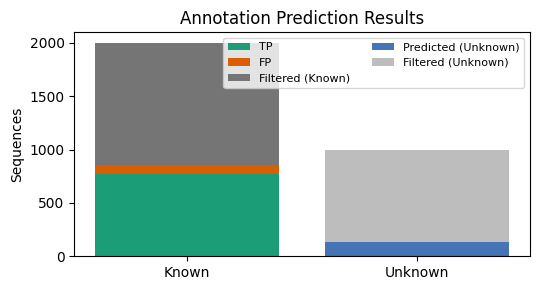

In [58]:
################################ 
conf_cutoff = .95 # confidence (0-1) 
score_cutoff = None # cosine similarity score; None=skip 
delta_cutoff = None # top1-top2; None=skip 
# ################################

apply_csv = "apply/output/apply/kmer_summary_test_sequences_1.csv"
ann_path  = "../../resources/demo_sequences/learn_apply_inputs/annotations/TIGRFAMs_annotation.ann"

# --- load & prep ---
df = pd.read_csv(apply_csv)
df.columns = [c.strip().capitalize() for c in df.columns]
df["Accession"] = df["Sequence"].str.split("|").str[1].fillna(df["Sequence"])
ann = pd.read_csv(ann_path, sep="\t").rename(columns={"id":"Accession","family":"Truefamily"})
df = df.merge(ann, on="Accession", how="left")
known, pred = df["Truefamily"].notna(), df["Prediction"].notna()

# kept (positives) vs filtered (negatives)
kept = pd.Series(True, index=df.index)
if conf_cutoff  is not None: kept &= df["Confidence"] >= conf_cutoff
if score_cutoff is not None: kept &= df["Score"]      >= score_cutoff
if delta_cutoff is not None: kept &= df["Delta"]      >= delta_cutoff
corr = known & pred & (df["Prediction"] == df["Truefamily"])

# counts
TP  = int((kept & corr).sum())
FP  = int((kept & known & pred & ~corr).sum())
FK  = int((~kept & known).sum())                 # Filtered (Known)
UP  = int((~known & kept & pred).sum())          # Predicted (Unassigned)
FU  = int((~known & ~kept).sum())                # Filtered (Unassigned)

# metrics (on knowns)
prec = TP/(TP+FP) if TP+FP else np.nan
rec  = TP/(TP+FK) if TP+FK else np.nan
print(f"total: {len(df)}  kept: {int(kept.sum())}")
print(f"TP:{TP}  FP:{FP}  Filtered(Known):{FK}  Predicted(Unknown):{UP}  Filtered(Unknown):{FU}")
print("precision:", np.round(prec,4) if np.isfinite(prec) else prec,
      " recall:", np.round(rec,4) if np.isfinite(rec) else rec)

# --- plot (stacked bars) ---
colors = {"TP":"#1b9e77","FP":"#d95f02","Filtered (Known)":"#757575",
          "Predicted (Unknown)":"#4575b4","Filtered (Unknown)":"#bdbdbd"}
fig, ax = plt.subplots(figsize=(5.5,3))
bot=0
for k,v in {"TP":TP,"FP":FP,"Filtered (Known)":FK}.items():
    ax.bar("Known", v, bottom=bot, color=colors[k], label=k); bot+=v
bot=0
for k,v in {"Predicted (Unknown)":UP,"Filtered (Unknown)":FU}.items():
    ax.bar("Unknown", v, bottom=bot, color=colors[k], label=k); bot+=v
ax.set_title("Annotation Prediction Results"); ax.set_ylabel("Sequences")
h,l = ax.get_legend_handles_labels(); u = dict(zip(l,h))
ax.legend(u.values(), u.keys(), ncol=2, fontsize=8)
plt.tight_layout(); plt.show()
